# Stage 3: EDA and Leakage Audit

Understand the Online Retail II transaction log before building features from it.
Transaction grain first, then customer grain at the Stage 0 cutoff.

No data files are produced here. The output is the drop list and feature list at the end.

In [1]:
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
sys.path.append(str(PROJECT_ROOT))

# Data directory
DATA_DIR = Path(PROJECT_ROOT, "data")
DATA_DIR.mkdir(exist_ok=True)

In [2]:
import matplotlib.pyplot as plt
import polars as pl

from src.config import CUTOFF_DATE, HORIZON_DAYS, PREDICTION_END, RAW_PARQUET
from src.logger import setup_logger

logger = setup_logger("01-eda")

pl.Config.set_tbl_rows(30)

logger.info("observation window ends: %s", CUTOFF_DATE.date())
logger.info("prediction window: %s to %s (%d days)", CUTOFF_DATE.date(), PREDICTION_END.date(), HORIZON_DAYS)

18:30:07 | 01-eda | INFO | observation window ends: 2011-09-11


18:30:07 | 01-eda | INFO | prediction window: 2011-09-11 to 2011-12-10 (90 days)


## 1. Load and first look

Loading the Parquet from Stage 2. Adding `line_revenue` because most questions below are
really about money.

Expecting about 1.07M rows across two source sheets.

In [3]:
df = pl.read_parquet(RAW_PARQUET).with_columns(
    (pl.col("quantity") * pl.col("price")).alias("line_revenue")
)

logger.info("shape: %s rows x %s columns", f"{df.height:,}", df.width)
logger.info("dates: %s to %s", df["invoice_date"].min(), df["invoice_date"].max())
display(df.group_by("source_sheet").len().sort("source_sheet"))
display(df.head(3))

18:30:07 | 01-eda | INFO | shape: 1,067,371 rows x 10 columns


18:30:07 | 01-eda | INFO | dates: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


source_sheet,len
str,u32
"""Year 2009-2010""",525461
"""Year 2010-2011""",541910


invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,source_sheet,line_revenue
str,str,str,i64,datetime[μs],f64,i64,str,str,f64
"""489434""","""85048""","""15CM CHRISTMAS GLASS BALL 20 L…",12,2009-12-01 07:45:00,6.95,13085,"""United Kingdom""","""Year 2009-2010""",83.4
"""489434""","""79323P""","""PINK CHERRY LIGHTS""",12,2009-12-01 07:45:00,6.75,13085,"""United Kingdom""","""Year 2009-2010""",81.0
"""489434""","""79323W""",""" WHITE CHERRY LIGHTS""",12,2009-12-01 07:45:00,6.75,13085,"""United Kingdom""","""Year 2009-2010""",81.0


1,067,371 rows, 525,461 and 541,910 across the two sheets. Dates run 2009-12-01 07:45 to
2011-12-09 12:50.

The grain is one invoice line, not one order: invoice 489434 uses three rows in the sample
above. So customer frequency must count distinct invoices, never rows.

## 2. Missing values

Real nulls first, then disguised ones: values stored as strings that actually mean
"missing". A null count will never show those.

In [4]:
nulls = (
    df.null_count()
    .transpose(include_header=True, header_name="column", column_names=["n_null"])
    .with_columns((100 * pl.col("n_null") / df.height).round(2).alias("pct"))
)
display(nulls)

for col in ["invoice", "stock_code", "description", "country"]:
    n_blank = df.filter(pl.col(col).str.strip_chars().str.len_chars() == 0).height
    logger.info("blank/whitespace in %-12s %d", col, n_blank)

logger.info("very short descriptions:")
display(
    df.filter(pl.col("description").str.strip_chars().str.len_chars() <= 3)
    .group_by("description").len().sort("len", descending=True)
)

column,n_null,pct
str,u32,f64
"""invoice""",0,0.0
"""stock_code""",0,0.0
"""description""",4382,0.41
"""quantity""",0,0.0
"""invoice_date""",0,0.0
"""price""",0,0.0
"""customer_id""",243007,22.77
"""country""",0,0.0
"""source_sheet""",0,0.0


18:30:07 | 01-eda | INFO | blank/whitespace in invoice      0


18:30:07 | 01-eda | INFO | blank/whitespace in stock_code   0


18:30:07 | 01-eda | INFO | blank/whitespace in description  0


18:30:07 | 01-eda | INFO | blank/whitespace in country      0


18:30:07 | 01-eda | INFO | very short descriptions:


description,len
str,u32
"""?""",92
"""??""",7
"""MIA""",5
"""wet""",2
"""FBA""",1
"""???""",1


Only two columns have real nulls: `customer_id` at 243,007 (22.77 percent) and
`description` at 4,382 (0.41 percent). No blank or whitespace-only strings.

The short descriptions are the interesting bit. `?`, `??`, `???`, `MIA`, `wet`, `FBA` are
not product names, they are warehouse notes typed into a product field. First hint that
this table holds rows which are not customer purchases. Section 3 follows that.

### 2a. What does the missing `customer_id` cost us?

A customer-level model cannot use unattributed rows, so they leave the population. 23
percent of rows sounds bad, so it needs sizing.

Also checking whether attribution is clean at invoice level. If one invoice could be half
attributed, aggregation gets delicate.

In [5]:
null_cust = df.filter(pl.col("customer_id").is_null())

logger.info("rows     : %s (%.1f%%)", f"{null_cust.height:,}", 100 * null_cust.height / df.height)
logger.info("revenue  : %.1f%% of total", 100 * null_cust["line_revenue"].sum() / df["line_revenue"].sum())
logger.info("invoices : %s of %s", f"{null_cust['invoice'].n_unique():,}", f"{df['invoice'].n_unique():,}")

mixed = (
    df.group_by("invoice")
    .agg(pl.col("customer_id").null_count().alias("n_null"), pl.len().alias("n_rows"))
    .filter((pl.col("n_null") > 0) & (pl.col("n_null") < pl.col("n_rows")))
)
logger.info("invoices mixing attributed and unattributed rows: %d", mixed.height)
logger.info("distinct customers, nulls dropped: %s", f"{df['customer_id'].drop_nulls().n_unique():,}")

18:30:07 | 01-eda | INFO | rows     : 243,007 (22.8%)


18:30:07 | 01-eda | INFO | revenue  : 13.7% of total


18:30:07 | 01-eda | INFO | invoices : 8,752 of 53,628


18:30:07 | 01-eda | INFO | invoices mixing attributed and unattributed rows: 0


18:30:07 | 01-eda | INFO | distinct customers, nulls dropped: 5,942


22.8 percent of rows but only **13.7 percent of revenue**, across 8,752 of 53,628 invoices.
Smaller than average baskets, which is what an unattributed till sale looks like.

**Zero invoices mix attributed and unattributed rows.** Attribution is decided per invoice,
so dropping these cannot leave a customer with half an order counted. Aggregation is safe.

There are **5,942** distinct customers. Note `n_unique()` without dropping nulls returns
5,943 because it counts null as a value.

Decision: these rows leave in Stage 5 as a population filter, not in Stage 4 cleaning.
Cleaning and population definition are different jobs.

## 3. Is every row a purchase?

The docs say a `C` prefix on the invoice marks a cancellation. Checking that against
negative quantities, since those two ought to be the same set of rows. If they are not,
whatever sits in the gap is something I do not understand yet.

In [6]:
c_prefix = pl.col("invoice").str.starts_with("C")
neg_qty = pl.col("quantity") < 0

logger.info("C-prefixed        : %s", f"{df.filter(c_prefix).height:,}")
logger.info("negative quantity : %s", f"{df.filter(neg_qty).height:,}")
logger.info("both              : %s", f"{df.filter(c_prefix & neg_qty).height:,}")
logger.info("C but not negative: %s", f"{df.filter(c_prefix & ~neg_qty).height:,}")
logger.info("negative but not C: %s   <-- gap", f"{df.filter(neg_qty & ~c_prefix).height:,}")

gap = df.filter(neg_qty & ~c_prefix)
logger.info("")
logger.info("the gap rows: price %.2f to %.2f, %.1f%% have no customer_id",
            gap["price"].min(), gap["price"].max(),
            100 * gap["customer_id"].null_count() / gap.height)
display(gap.group_by("description").len().sort("len", descending=True).head(12))

18:30:07 | 01-eda | INFO | C-prefixed        : 19,494


18:30:07 | 01-eda | INFO | negative quantity : 22,950


18:30:07 | 01-eda | INFO | both              : 19,493


18:30:07 | 01-eda | INFO | C but not negative: 1


18:30:07 | 01-eda | INFO | negative but not C: 3,457   <-- gap


18:30:07 | 01-eda | INFO | 


18:30:07 | 01-eda | INFO | the gap rows: price 0.00 to 0.00, 100.0% have no customer_id


description,len
str,u32
null,2689
"""check""",123
"""damages""",84
"""?""",83
"""damaged""",78
"""missing""",27
"""sold as set on dotcom""",20
"""Damaged""",17
"""Unsaleable, destroyed.""",9


They do not match. 19,493 rows agree, one lone `C` row is not negative, and **3,457 rows
are negative with no `C` prefix**.

Those 3,457 are not customer returns:

- every one has `price = 0.00`
- every one has a null `customer_id`
- descriptions are `check`, `damages`, `damaged`, `missing`, `smashed`, `thrown away`,
  `Unsaleable, destroyed.`, or null

These are **warehouse stock write-offs**, inventory being reconciled. Treating them as
returns would invent return behaviour for customers who never returned anything.

So `is_cancellation` must come from the `C` prefix, not from `quantity < 0`.

### 3a. Are there only two kinds of invoice?

The docs imply numeric and `C`. After the last result I would rather classify every invoice
than assume. Anything landing in `UNCLASSIFIED` is something I missed.

In [7]:
invoice_kind = (
    pl.when(pl.col("invoice").str.contains(r"^\d+$")).then(pl.lit("numeric"))
    .when(pl.col("invoice").str.starts_with("C")).then(pl.lit("C prefix"))
    .otherwise(pl.lit("UNCLASSIFIED"))
)

display(
    df.with_columns(invoice_kind.alias("kind"))
    .group_by("kind")
    .agg(
        pl.len().alias("rows"),
        pl.col("invoice").n_unique().alias("invoices"),
        pl.col("line_revenue").sum().round(0).alias("revenue"),
    )
    .sort("rows", descending=True)
)

unclassified = df.filter(invoice_kind == "UNCLASSIFIED")
if unclassified.height:
    display(unclassified.select(
        "invoice", "stock_code", "description", "quantity", "price", "customer_id"
    ))

kind,rows,invoices,revenue
str,u32,u32,f64
"""numeric""",1047871,45330,2.0961533e7
"""C prefix""",19494,8292,-1.526668e6
"""UNCLASSIFIED""",6,6,-147614.0


invoice,stock_code,description,quantity,price,customer_id
str,str,str,i64,f64,i64
"""A506401""","""B""","""Adjust bad debt""",1,-53594.36,null
"""A516228""","""B""","""Adjust bad debt""",1,-44031.79,null
"""A528059""","""B""","""Adjust bad debt""",1,-38925.87,null
"""A563185""","""B""","""Adjust bad debt""",1,11062.06,null
"""A563186""","""B""","""Adjust bad debt""",1,-11062.06,null
"""A563187""","""B""","""Adjust bad debt""",1,-11062.06,null


The catch-all caught something. There is a **third invoice prefix**, `A`, which nothing
documented:

| kind | rows | invoices | revenue |
|---|---|---|---|
| numeric | 1,047,871 | 45,330 | 20,961,533 |
| `C` prefix | 19,494 | 8,292 | -1,526,668 |
| `A` prefix | 6 | 6 | **-147,614** |

Six rows, all `Adjust bad debt`, stock code `B`, no customer, one at -53,594. Six rows out
of a million carrying 147,614 of negative revenue, enough to distort any revenue total.
They are accounting entries, not transactions. Dropped in Stage 4.

Worth noting this only surfaced because the classification had an `UNCLASSIFIED` bucket.
A filter written as "C or not C" would have counted these as ordinary purchases.

## 4. Stock code taxonomy

Real product codes look like 5 digits with an optional letter suffix (`85123A`). Listing
everything that does not match, so the non-product rows can be named rather than guessed
at.

Expecting mostly postage and fees, which would all get dropped.

In [8]:
standard = pl.col("stock_code").str.contains(r"^\d{5}\w*$")
non_std = df.filter(~standard)

logger.info("standard codes    : %s rows (%.2f%%)",
            f"{df.filter(standard).height:,}", 100 * df.filter(standard).height / df.height)
logger.info("non-standard codes: %s rows (%.2f%%), %d distinct",
            f"{non_std.height:,}", 100 * non_std.height / df.height, non_std["stock_code"].n_unique())

pl.Config.set_tbl_rows(65)
display(
    non_std.group_by("stock_code")
    .agg(
        pl.len().alias("rows"),
        pl.col("description").drop_nulls().first().alias("example_description"),
    )
    .sort("rows", descending=True)
)

18:30:07 | 01-eda | INFO | standard codes    : 1,061,277 rows (99.43%)


18:30:07 | 01-eda | INFO | non-standard codes: 6,094 rows (0.57%), 63 distinct


stock_code,rows,example_description
str,u32,str
"""POST""",2122,"""POSTAGE"""
"""DOT""",1446,"""DOTCOM POSTAGE"""
"""M""",1421,"""Manual"""
"""C2""",282,"""CARRIAGE"""
"""D""",177,"""Discount"""
"""S""",104,"""SAMPLES"""
"""BANK CHARGES""",102,""" Bank Charges"""
"""ADJUST""",67,"""Adjustment by john on 26/01/20…"
"""AMAZONFEE""",43,"""AMAZON FEE"""


6,094 rows (0.57 percent), 63 distinct codes. My expectation that these are all fees was
wrong.

| Group | Codes | Verdict |
|---|---|---|
| Shipping | `POST`, `DOT`, `C2`, `C3` | drop |
| Fees and accounting | `M`, `m`, `D`, `S`, `BANK CHARGES`, `AMAZONFEE`, `CRUK`, `B`, `ADJUST`, `ADJUST2`, `PADS` | drop |
| Test rows | `TEST001`, `TEST002` | drop, described as "This is a test product." |
| Vouchers | `gift_0001_*`, `GIFT` | drop, a voucher is payment not product |
| **Real products** | `DCGS*`, `SP1002` | **keep** |
| **Whitespace** | `47503J ` | **keep**, needs trimming |

Two things I would have got wrong by pattern alone:

1. The `DCGS` codes look like junk but are genuine items: `MISO PRETTY GUM`,
   `SUNJAR LED NIGHT LIGHT`, `BOXED GLASS ASHTRAY`, `OOH LA LA DOGS COLLAR`,
   `HAYNES CAMPER SHOULDER BAG`. A different catalogue convention, not garbage. `SP1002` is
   `KID'S CHALKBOARD/EASEL`.
2. `47503J ` has a **trailing space**. It is an ordinary product code that failed the regex
   on whitespace alone.

So Stage 4 strips whitespace from `stock_code` first, then drops by an **explicit code
list**, never by pattern.

## 5. Price and quantity

Looking for impossible and extreme values. The thing I actually need to decide is whether
the extremes are data errors (clip them) or real bulk orders (leave them alone).

In [9]:
pl.Config.set_tbl_rows(15)

zero_price = df.filter(pl.col("price") == 0)
logger.info("price == 0: %s rows, %.1f%% with no customer_id",
            f"{zero_price.height:,}", 100 * zero_price["customer_id"].null_count() / zero_price.height)
logger.info("price <  0: %s rows", f"{df.filter(pl.col('price') < 0).height:,}")

logger.info("quantity: median %.0f | p99 %.0f | min %s | max %s",
            df["quantity"].median(), df["quantity"].quantile(0.99),
            f"{df['quantity'].min():,}", f"{df['quantity'].max():,}")

logger.info("the most extreme quantities:")
display(
    df.filter(pl.col("quantity").abs() > 70_000)
    .select("invoice", "stock_code", "description", "quantity", "price", "customer_id", "invoice_date")
    .sort("quantity")
)

18:30:07 | 01-eda | INFO | price == 0: 6,202 rows, 98.9% with no customer_id


18:30:07 | 01-eda | INFO | price <  0: 5 rows


18:30:07 | 01-eda | INFO | quantity: median 3 | p99 100 | min -80,995 | max 80,995


18:30:07 | 01-eda | INFO | the most extreme quantities:


invoice,stock_code,description,quantity,price,customer_id,invoice_date
str,str,str,i64,f64,i64,datetime[μs]
"""C581484""","""23843""","""PAPER CRAFT , LITTLE BIRDIE""",-80995,2.08,16446,2011-12-09 09:27:00
"""C541433""","""23166""","""MEDIUM CERAMIC TOP STORAGE JAR""",-74215,1.04,12346,2011-01-18 10:17:00
"""541431""","""23166""","""MEDIUM CERAMIC TOP STORAGE JAR""",74215,1.04,12346,2011-01-18 10:01:00
"""581483""","""23843""","""PAPER CRAFT , LITTLE BIRDIE""",80995,2.08,16446,2011-12-09 09:15:00


6,202 zero-price rows, 98.9 percent with no customer, so mostly the same warehouse
bookkeeping from section 3. Only 5 negative prices, all the `A` bad-debt rows.

Quantity runs -80,995 to 80,995 against a median of 3. But look at the timestamps: invoice
581483 sells 80,995 `PAPER CRAFT , LITTLE BIRDIE` at 09:15, and `C581484` cancels exactly
that at 09:27, same customer, same product, 12 minutes later. The second pair does the
same 16 minutes apart.

**So the extremes are real orders that were cancelled, not data errors. Do not clip.**
Summing revenue with returns negative already handles them.

## 6. Duplicate rows

In [10]:
n_dupe = df.height - df.unique().height
logger.info("exact duplicate rows: %s (%.2f%%)", f"{n_dupe:,}", 100 * n_dupe / df.height)

display(
    df.group_by(df.columns).len()
    .filter(pl.col("len") > 1)
    .sort("len", descending=True)
    .select("invoice", "stock_code", "description", "quantity", "price", "len")
    .head(5)
)

18:30:08 | 01-eda | INFO | exact duplicate rows: 12,133 (1.14%)


invoice,stock_code,description,quantity,price,len
str,str,str,i64,f64,u32
"""555524""","""22698""","""PINK REGENCY TEACUP AND SAUCER""",1,2.95,20
"""555524""","""22697""","""GREEN REGENCY TEACUP AND SAUCE…",1,2.95,12
"""572861""","""22775""","""PURPLE DRAWERKNOB ACRYLIC EDWA…",12,1.25,8
"""541266""","""21755""","""LOVE BUILDING BLOCK WORD""",1,5.95,6
"""496431""","""84826""","""ASSTD DESIGN 3D PAPER STICKERS""",1,0.85,6


12,133 duplicate rows (1.14 percent). Invoice 555524 has the same teacup line 20 times.

Genuinely ambiguous: a till scanning one item 20 times, or a broken export. Nothing in the
data distinguishes them.

**Keep them.** The features that matter here are invoice level (recency, frequency, order
counts) and duplicate lines do not change the invoice count at all. Only monetary totals
are exposed. Revisit if monetary features misbehave later.

## 7. Country

The only categorical that becomes a feature. Its shape decides how the vocabulary gets
pinned in Stage 5. Also checking whether a customer can have more than one country, which
would make it a transaction property rather than a customer property.

In [11]:
attributed = df.filter(pl.col("customer_id").is_not_null())

by_country = (
    attributed.group_by("country")
    .agg(pl.col("customer_id").n_unique().alias("customers"))
    .sort("customers", descending=True)
)
total = by_country["customers"].sum()

logger.info("distinct countries: %d", by_country.height)
display(by_country.head(12))

for n in [1, 5, 10, 15]:
    logger.info("top %2d cover %.1f%% of customers", n, 100 * by_country.head(n)["customers"].sum() / total)
logger.info("countries with fewer than 20 customers: %d", by_country.filter(pl.col("customers") < 20).height)

multi = (
    attributed.group_by("customer_id")
    .agg(pl.col("country").n_unique().alias("n"))
    .filter(pl.col("n") > 1)
)
logger.info("customers with more than one country: %d", multi.height)

18:30:08 | 01-eda | INFO | distinct countries: 41


country,customers
str,u32
"""United Kingdom""",5410
"""Germany""",107
"""France""",95
"""Spain""",41
"""Belgium""",29
"""Portugal""",24
"""Netherlands""",23
"""Switzerland""",22
"""Sweden""",19


18:30:08 | 01-eda | INFO | top  1 cover 90.8% of customers


18:30:08 | 01-eda | INFO | top  5 cover 95.4% of customers


18:30:08 | 01-eda | INFO | top 10 cover 97.2% of customers


18:30:08 | 01-eda | INFO | top 15 cover 98.4% of customers


18:30:08 | 01-eda | INFO | countries with fewer than 20 customers: 33


18:30:08 | 01-eda | INFO | customers with more than one country: 13


41 countries, and the concentration is severe. The UK alone is **90.8 percent** of
customers, the top 5 are 95.4 percent, and **33 of 41 countries have fewer than 20
customers**.

One-hot encoding all 41 would produce columns that are almost all zero, several appearing
in train and never in test or the reverse. That is the train/serve mismatch we are supposed
to prevent.

Stage 5: pin `COUNTRY_VOCAB` to countries above a minimum customer count and map the rest
to `Other`. On this table a cut at 20 customers keeps 8 countries plus `Other`, covering
about 96 percent of customers directly.

Also, **13 customers appear under more than one country**, so country belongs to the
transaction, not the customer. Stage 5 has to pick one deliberately: most recent country is
the right choice, since that is what would be known at scoring time.

## 8. Customer level: population and label

Changing grain. From here the unit is the customer as of the cutoff.

Two filters decide who can be modelled: identifiable (non-null id) and made a genuine
purchase before the cutoff. A customer whose only pre-cutoff activity is a cancellation has
no purchase to compute recency or frequency from.

Stage 2 previewed 5,346 customers at a 43.4 percent base rate, but that did not exclude
cancellation-only customers, so this should come out slightly lower.

In [12]:
is_purchase = ~pl.col("invoice").str.starts_with("C")

observation = attributed.filter(pl.col("invoice_date") < CUTOFF_DATE)
prediction = attributed.filter(
    (pl.col("invoice_date") >= CUTOFF_DATE) & (pl.col("invoice_date") < PREDICTION_END)
)
obs_purchases = observation.filter(is_purchase)
pred_purchases = prediction.filter(is_purchase)

population = obs_purchases.select("customer_id").unique()
logger.info("any pre-cutoff activity : %s", f"{observation['customer_id'].n_unique():,}")
logger.info("made a real purchase    : %s", f"{population.height:,}")
logger.info("dropped, cancel-only    : %s",
            f"{observation['customer_id'].n_unique() - population.height:,}")

labels = (
    population
    .join(pred_purchases.select("customer_id").unique().with_columns(pl.lit(1).alias("y")),
          on="customer_id", how="left")
    .with_columns(pl.col("y").fill_null(0))
)
display(labels.group_by("y").len().sort("y"))
logger.info("BASE RATE: %.3f", labels["y"].mean())

18:30:08 | 01-eda | INFO | any pre-cutoff activity : 5,346


18:30:08 | 01-eda | INFO | made a real purchase    : 5,283


18:30:08 | 01-eda | INFO | dropped, cancel-only    : 63


y,len
i32,u32
0,2991
1,2292


18:30:08 | 01-eda | INFO | BASE RATE: 0.434


**5,283 customers**, 2,991 non-repeat and 2,292 repeat, base rate **0.434**. 63 dropped as
cancellation-only, as predicted.

Two things this settles:

1. **Nearly balanced.** Imbalance is not the problem here, so the threshold tuning in
   Stage 8 is justified by the asymmetric cost of the two errors, not by skew. No class
   weighting, no resampling.
2. **The table is small.** 5,283 rows means roughly 850 per CV fold. Fold variance will be
   visible and small metric gaps between models will often be noise. Stage 7 has to report
   fold standard deviations, not just means.

## 9. Is the RFM signal actually there?

The whole project assumes recency, frequency and monetary predict return. Worth checking
before building 25 features on that assumption.

Computed the way Stage 5 will: observation-window purchases only, recency measured against
`CUTOFF_DATE`, never against the data's own max date.

Expecting recency to separate best. Genuinely unsure about tenure.

In [13]:
rfm = (
    obs_purchases.group_by("customer_id")
    .agg(
        (CUTOFF_DATE - pl.col("invoice_date").max()).dt.total_days().alias("recency_days"),
        pl.col("invoice").n_unique().alias("frequency"),
        pl.col("line_revenue").sum().alias("monetary"),
        (CUTOFF_DATE - pl.col("invoice_date").min()).dt.total_days().alias("tenure_days"),
    )
    .join(labels, on="customer_id")
)

display(
    rfm.group_by("y").agg(
        pl.col("recency_days").median().alias("recency"),
        pl.col("frequency").median().alias("frequency"),
        pl.col("monetary").median().round(0).alias("monetary"),
        pl.col("tenure_days").median().alias("tenure"),
    ).sort("y")
)

logger.info("correlation with label:")
for col in ["recency_days", "frequency", "monetary", "tenure_days"]:
    r = rfm.select(pl.corr(pl.col(col).cast(pl.Float64), pl.col("y").cast(pl.Float64))).item()
    logger.info("  %-14s %+.3f", col, r)

y,recency,frequency,monetary,tenure
i32,f64,f64,f64,f64
0,288.0,2.0,496.0,459.0
1,67.0,5.0,1656.0,502.0


18:30:08 | 01-eda | INFO | correlation with label:


18:30:08 | 01-eda | INFO |   recency_days   -0.437


18:30:08 | 01-eda | INFO |   frequency      +0.268


18:30:08 | 01-eda | INFO |   monetary       +0.141


18:30:08 | 01-eda | INFO |   tenure_days    +0.044


The signal is there and the ranking is clear.

| | median, y=0 | median, y=1 | correlation |
|---|---|---|---|
| `recency_days` | 288 | **67** | **-0.437** |
| `frequency` | 2 | 5 | +0.268 |
| `monetary` | 496 | 1,656 | +0.141 |
| `tenure_days` | 459 | 502 | **+0.044** |

**Tenure is the useful surprise.** At +0.044 it carries essentially nothing, and its medians
barely move (459 vs 502). How long someone has been a customer tells us almost nothing;
how recently they bought tells us a lot.

It still earns a place in Stage 5, but as a **denominator, not a predictor**: recency
divided by the customer's own typical gap between orders. 60 days of silence means
something different for a weekly buyer than an annual one. Stage 9 will show if that held.

### 9a. Distribution shape

Correlation compresses a lot into one number. The shape decides whether a linear model can
use these directly, so plotting them and measuring skew alongside.

18:30:08 | 01-eda | INFO | recency_days   skew +0.7


18:30:08 | 01-eda | INFO | frequency      skew +11.1


18:30:08 | 01-eda | INFO | monetary       skew +24.0


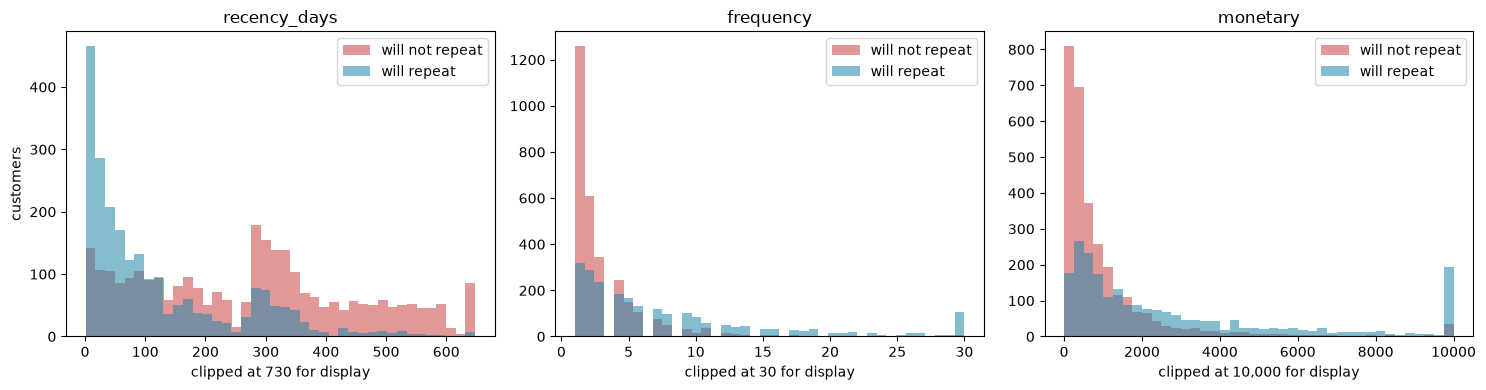

In [14]:
for col in ["recency_days", "frequency", "monetary"]:
    logger.info("%-14s skew %+.1f", col, rfm[col].skew())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pdf = rfm.to_pandas()

for ax, col, cap in zip(axes, ["recency_days", "frequency", "monetary"], [730, 30, 10_000]):
    for label, name, colour in [(0, "will not repeat", "#c44"), (1, "will repeat", "#28a")]:
        ax.hist(pdf.loc[pdf["y"] == label, col].clip(upper=cap),
                bins=40, alpha=0.55, label=name, color=colour)
    ax.set_title(col)
    ax.set_xlabel(f"clipped at {cap:,} for display")
    ax.legend()

axes[0].set_ylabel("customers")
plt.tight_layout()
plt.show()

Recency skew is only **+0.7**, close to symmetric, and the histogram shows repeaters piled
near zero with non-repeaters spread wide.

Frequency (**+11.1**) and monetary (**+24.0**) are a different matter. Both are extremely
right skewed: most customers at the low end, a thin tail of heavy buyers.

That is a problem for Logistic Regression, which fits a linear function of the inputs, and
a non-problem for gradient boosting, which only cares about ordering. Rather than
transforming, the ratio features planned for Stage 5 (recency over average gap, spend
momentum) are naturally scale free and should help the linear model without special
handling. If the Stage 6 baseline underperforms badly, this skew is the first thing to
revisit.

## 10. The incumbent baseline: RFM quintile heuristic

The rule a marketing team runs in a spreadsheet with no model: score 1 to 5 on each of R, F
and M, add them, target the low totals. This is the real competitor, so building it here
gives Stage 6 a concrete specification.

Expecting monotonic repeat rates. If they are not monotonic something upstream is wrong.

In [15]:
scored = rfm.with_columns(
    # Recency reversed: fewer days since the last order is a better score.
    pl.col("recency_days").qcut(5, labels=["5", "4", "3", "2", "1"]).cast(pl.Utf8).cast(pl.Int32).alias("r_score"),
    pl.col("frequency").qcut(5, labels=["1", "2", "3", "4", "5"], allow_duplicates=True).cast(pl.Utf8).cast(pl.Int32).alias("f_score"),
    pl.col("monetary").qcut(5, labels=["1", "2", "3", "4", "5"]).cast(pl.Utf8).cast(pl.Int32).alias("m_score"),
).with_columns((pl.col("r_score") + pl.col("f_score") + pl.col("m_score")).alias("rfm_score"))

for dim in ["r_score", "f_score", "m_score"]:
    logger.info("%s:", dim)
    display(
        scored.group_by(dim)
        .agg(pl.len().alias("customers"), pl.col("y").mean().round(3).alias("repeat_rate"))
        .sort(dim)
    )

combined = (
    scored.group_by("rfm_score")
    .agg(pl.len().alias("customers"), pl.col("y").mean().round(3).alias("repeat_rate"))
    .sort("rfm_score")
)
display(combined)

18:30:11 | 01-eda | INFO | r_score:


r_score,customers,repeat_rate
i32,u32,f64
1,1056,0.132
2,1057,0.291
3,1056,0.399
4,1030,0.595
5,1084,0.748


18:30:11 | 01-eda | INFO | f_score:


f_score,customers,repeat_rate
i32,u32,f64
1,1578,0.202
2,897,0.323
3,1006,0.417
4,747,0.558
5,1055,0.803


18:30:11 | 01-eda | INFO | m_score:


m_score,customers,repeat_rate
i32,u32,f64
1,1057,0.184
2,1056,0.284
3,1057,0.395
4,1056,0.53
5,1057,0.777


rfm_score,customers,repeat_rate
i32,u32,f64
3,404,0.072
4,446,0.148
5,460,0.215
6,435,0.244
7,466,0.335
8,424,0.384
9,422,0.405
10,373,0.448
11,390,0.544


All three are cleanly monotonic:

| score | R | F | M |
|---|---|---|---|
| 1 (worst) | 0.132 | 0.202 | 0.184 |
| 2 | 0.291 | 0.323 | 0.284 |
| 3 | 0.399 | 0.417 | 0.395 |
| 4 | 0.595 | 0.558 | 0.530 |
| 5 (best) | 0.748 | 0.803 | 0.777 |

Combined, the spread is wider: score 3 repeats **7.2 percent** of the time, score 15 repeats
**90.6 percent**.

**This raises the bar a lot.** A spreadsheet rule already separates the population from 0.07
to 0.91. A boosted model reaching 0.80 ROC-AUC is not obviously an improvement on that.
This is why Stage 0 requires beating the heuristic by more than the fold-to-fold standard
deviation, and why Stage 6 has to report this and not just the majority-class floor.

## 11. Two candidate features

Both cheap to test and both would change what Stage 5 builds.

1. **Single-order customers.** Predict they repeat much less and deserve their own flag.
2. **Cancellation behaviour.** Predict customers who return things are less satisfied and
   so repeat less.

In [16]:
single = rfm.filter(pl.col("frequency") == 1)
multi = rfm.filter(pl.col("frequency") > 1)
logger.info("single-order: %s (%.1f%%), repeat rate %.3f",
            f"{single.height:,}", 100 * single.height / rfm.height, single["y"].mean())
logger.info("multi-order : %s (%.1f%%), repeat rate %.3f",
            f"{multi.height:,}", 100 * multi.height / rfm.height, multi["y"].mean())

cancels = (
    observation.filter(pl.col("invoice").str.starts_with("C"))
    .group_by("customer_id").agg(pl.col("invoice").n_unique().alias("cancel_orders"))
)
with_cancels = rfm.join(cancels, on="customer_id", how="left").with_columns(
    pl.col("cancel_orders").fill_null(0)
)
has = with_cancels.filter(pl.col("cancel_orders") > 0)
none = with_cancels.filter(pl.col("cancel_orders") == 0)

logger.info("")
logger.info("has cancelled  : %s (%.1f%%), repeat rate %.3f",
            f"{has.height:,}", 100 * has.height / with_cancels.height, has["y"].mean())
logger.info("never cancelled: %s (%.1f%%), repeat rate %.3f",
            f"{none.height:,}", 100 * none.height / with_cancels.height, none["y"].mean())

logger.info("median frequency, has cancelled %.0f vs never %.0f",
            has["frequency"].median(), none["frequency"].median())

18:30:11 | 01-eda | INFO | single-order: 1,578 (29.9%), repeat rate 0.202


18:30:11 | 01-eda | INFO | multi-order : 3,705 (70.1%), repeat rate 0.533


18:30:11 | 01-eda | INFO | 


18:30:11 | 01-eda | INFO | has cancelled  : 2,238 (42.4%), repeat rate 0.577


18:30:11 | 01-eda | INFO | never cancelled: 3,045 (57.6%), repeat rate 0.329


18:30:11 | 01-eda | INFO | median frequency, has cancelled 6 vs never 2


First prediction held, second was backwards.

**Single-order customers**: 1,578 (29.9 percent), repeat rate **0.202** against 0.533 for
multi-order. The flag is justified, and nearly a third of the population sitting in a
harder cohort is worth remembering for Stage 9 error analysis.

**Cancellations**: customers who have cancelled repeat at **0.577**, those who never have at
**0.329**. The opposite of what I predicted.

The last line explains it: **median frequency is 6 for cancellers and 2 for
non-cancellers**. Cancelling requires having ordered a lot first, so cancellation count is
largely a proxy for order volume, and that swamps any dissatisfaction effect.

So Stage 5 builds **`cancel_order_rate`** (cancellations as a share of the customer's own
orders) alongside the raw count, so the model can separate "returns a lot relative to how
much they buy" from "simply buys a lot".

Leaving the wrong prediction in place on purpose: when SHAP shows cancellation features
pushing predictions up in Stage 9, that is the data agreeing with this cell, not a bug.

## 12. Leakage audit

No post-outcome column exists in this schema, so the risk here is **temporal**: features and
label live in the same table, separated only by a date.

Three ways it could get in:

1. A post-cutoff transaction reaching a feature. Guarded by filtering to
   `invoice_date < CUTOFF_DATE` before any aggregation.
2. Recency measured against `max(invoice_date)` instead of `CUTOFF_DATE`. The subtle one:
   both look plausible, but the first encodes when the data ends, which does not exist at
   serving time.
3. A statistic fitted on the full table (target encoding, product popularity, scaler means).
   None planned; scalers go inside the pipeline in Stage 6.

Asserting the guard rather than trusting it.

In [17]:
assert observation["invoice_date"].max() < CUTOFF_DATE, "observation window has post-cutoff rows"
assert prediction["invoice_date"].min() >= CUTOFF_DATE, "prediction window has pre-cutoff rows"
assert df.filter(pl.col("invoice_date") >= PREDICTION_END).height == 0, "rows beyond the horizon"
logger.info("temporal guard holds")
logger.info("  last observation : %s", observation["invoice_date"].max())
logger.info("  first prediction : %s", prediction["invoice_date"].min())

shift = (df["invoice_date"].max() - CUTOFF_DATE).days
logger.info("anchoring recency to max(invoice_date) would shift every value by %d days,", shift)
logger.info("using information from inside the prediction window.")

18:30:11 | 01-eda | INFO | temporal guard holds


18:30:11 | 01-eda | INFO |   last observation : 2011-09-09 16:36:00


18:30:11 | 01-eda | INFO |   first prediction : 2011-09-11 10:35:00


18:30:11 | 01-eda | INFO | anchoring recency to max(invoice_date) would shift every value by 89 days,


18:30:11 | 01-eda | INFO | using information from inside the prediction window.


All three assertions pass. Nothing crosses the boundary and nothing falls beyond the
horizon.

Anchoring recency to `max(invoice_date)` would shift every value by **89 days**, drawn from
inside the prediction window. The model would look fine in evaluation and fail in
production.

One thing I did not expect: the observation window ends **2011-09-09 16:36** but the
prediction window starts **2011-09-11 10:35**. A day and a half of silence at the boundary.
Checking why rather than ignoring it.

In [18]:
from datetime import timedelta

weekday_names = {1: "Monday", 2: "Tuesday", 3: "Wednesday", 4: "Thursday",
                 5: "Friday", 6: "Saturday", 7: "Sunday"}

display(
    df.with_columns(pl.col("invoice_date").dt.weekday().alias("wd"))
    .group_by("wd").len().sort("wd")
    .with_columns(pl.col("wd").replace_strict(weekday_names).alias("day"))
    .select("day", "len")
)

gap_day = CUTOFF_DATE - timedelta(days=1)
logger.info("the silent day %s is a %s, with %d rows",
            gap_day.date(), weekday_names[gap_day.isoweekday()],
            df.filter(pl.col("invoice_date").dt.date() == gap_day.date()).height)

day,len
str,u32
"""Monday""",189084
"""Tuesday""",196626
"""Wednesday""",185051
"""Thursday""",203149
"""Friday""",153803
"""Saturday""",402
"""Sunday""",139256


18:30:11 | 01-eda | INFO | the silent day 2011-09-10 is a Saturday, with 0 rows


**The shop is shut on Saturdays.** 402 rows in two years against 139,000 to 203,000 on
every other day. Sunday trading is normal.

2011-09-10, the silent day, is a Saturday with **0 rows**. So the boundary gap is not a data
problem, it is the business being closed. The cutoff placement is fine and nothing was lost.

One consequence for Stage 5: **day-count features carry a weekly rhythm**. A
`recency_days` of 1 versus 3 can mean the same thing depending on where the cutoff lands.
Harmless at a 90-day horizon, but it is the reason not to build finer-grained time features
like hours since last order, which would encode a trading calendar the model cannot
interpret.

### Column classification

| Column | Class | Disposition |
|---|---|---|
| `customer_id` | identifier | join and group key, never a feature |
| `invoice` | transaction grain | becomes `frequency` and cancellation counts, dropped raw |
| `invoice_date` | temporal | source of recency, tenure, momentum. Never used raw |
| `stock_code` | transaction grain | becomes `distinct_products`. Per-product features on 5,283 customers would overfit |
| `description` | free text | **drop**, duplicates `stock_code` and holds warehouse notes |
| `quantity` | detail | becomes basket-size features |
| `price` | detail | becomes `avg_unit_price` |
| `country` | categorical | **keep**, pinned vocabulary plus `Other` |
| `source_sheet` | load artefact | **drop**, encodes trading year, a crude time proxy |
| `line_revenue` | derived | becomes monetary features |

No column duplicates the target and no post-outcome field exists. We construct the target
ourselves from the prediction window, so the only way to leak it is temporally.

## 13. Stage 3 report

### Target

`y = 1` if the customer places at least one non-cancelled order in
`[2011-09-11, 2011-12-10)`. Population 5,283, base rate **0.434**.

### Drop list

| Dropped | Size | Reason |
|---|---|---|
| Null `customer_id` rows | 243,007 (22.8 percent) | Unattributable. Only 13.7 percent of revenue, no invoice partially attributed. Applied in **Stage 5** as a population filter |
| `A`-prefixed invoices | 6 rows | Bad-debt accounting, -147,614 revenue |
| Negative quantity without `C` | 3,457 rows | Warehouse write-offs, all zero price and unattributed |
| Non-product `stock_code` | about 6,000 rows | Postage, fees, tests, vouchers |
| `description`, `source_sheet` | columns | Warehouse notes; time proxy |
| Cancellation-only customers | 63 | No purchase to compute recency from |

**Kept deliberately:** `DCGS*` and `SP1002` are real products; `47503J ` just needs
trimming; 12,133 duplicate rows do not affect invoice-level features.

### Data quality issues

1. Negative quantity is not a cancellation marker (3,457 write-offs).
2. Three invoice prefixes exist, not two.
3. Non-standard stock codes mix fees and real products.
4. `47503J ` has a trailing space, so `stock_code` needs trimming.
5. Disguised missing in `description`: `?`, `??`, `MIA`, `wet`, `FBA`.
6. 13 customers appear under more than one country.
7. Extreme quantities are real cancelled bulk orders. Do not clip.
8. No Saturday trading, so day-counts carry a weekly rhythm.

### Candidate features for Stage 5

| Group | Features |
|---|---|
| RFM core | `recency_days`, `frequency`, `monetary_total`, `monetary_avg_per_order` |
| Lifecycle | `tenure_days`, `avg_days_between_orders`, **`recency_over_avg_gap`**, `is_single_order_customer` |
| Basket | `avg_items_per_order`, `avg_distinct_products_per_order`, `avg_unit_price`, `total_quantity`, `distinct_products` |
| Returns | `cancel_order_count`, **`cancel_order_rate`**, `return_value_ratio` |
| Momentum | `orders_last_30d/90d/180d`, `spend_last_90d`, `spend_last_365d`, `spend_momentum` |
| Activity | `distinct_active_months` |
| Categorical | `country`, pinned vocabulary plus `Other` |

### Decisions carried forward

1. Stage 4 trims `stock_code` whitespace, then drops by **explicit code list**, never regex.
2. Stage 4 keeps duplicate rows and does not clip quantity.
3. Stage 5 pins `COUNTRY_VOCAB` at a minimum customer count (8 countries at a cut of 20),
   rest to `Other`, and resolves multi-country customers by most recent country.
4. Stage 5 builds `cancel_order_rate`, not just the count.
5. Stage 6 must report the RFM heuristic, not only the majority-class floor.
6. Stage 7 must report fold standard deviations, since 850 rows per fold is noisy.
7. Stage 9 should expect cancellation features to push predictions up.

### Open questions

- Does `recency_over_avg_gap` beat raw `recency_days`? Tenure alone is useless (+0.044), so
  the ratio framing is the hypothesis.
- Frequency and monetary are skewed +11 and +24. Does that hurt Logistic Regression enough
  to need a transform?

### Exit check

| Requirement | Where |
|---|---|
| Shape, dtypes, target, class balance | 1, 8 |
| Missing and disguised missing | 2 |
| Numeric distributions split by target | 9, 9a |
| Target rate per categorical level | 7, 10 |
| Correlations checked for leakage suspects | 9 |
| Leakage audit, every column classified | 12 |
| Drop list with reasons | 13 |
| Candidate features | 13 |

Stage 4 may begin.